In [1]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("/scratch/gpfs/jp7427/FVvsSD/sinus-timing/timing_results.csv")

MOOD_ROUTINES = (
    "candidate_solution",
    "detect_troubles",
    "fallback_fluxes",
    "assign_fluxes",
)

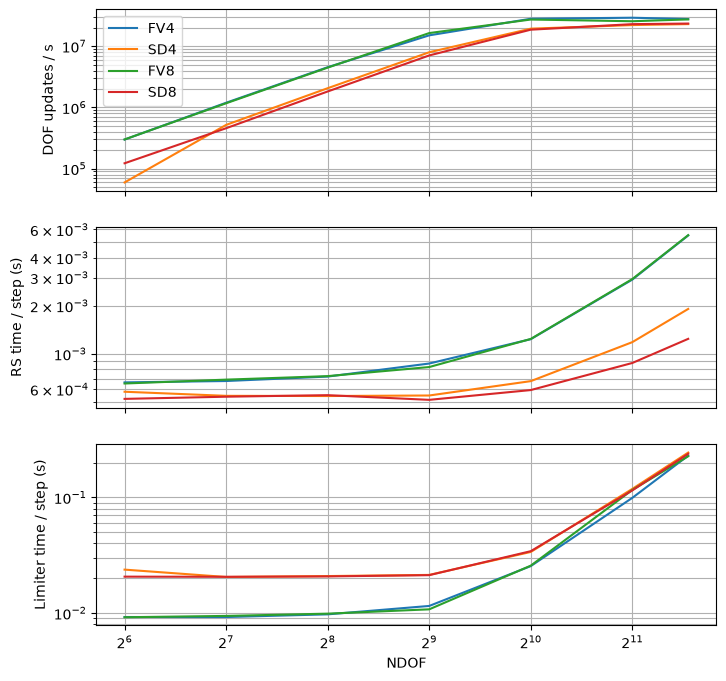

In [2]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(8, 8))
axs[2].set_xlabel("NDOF")
axs[0].set_ylabel("DOF updates / s")
axs[1].set_ylabel("RS time / step (s)")
axs[2].set_ylabel("Limiter time / step (s)")
axs[0].set_xscale("log", base=2)
for ax in axs:
    ax.set_yscale("log")

def plot(ax, df, quantity, **kwargs):
    ax.plot(df.NDOF, getattr(df, quantity), **kwargs)

plot(axs[0], df[(df.scheme == "FV") & (df.p == 3)], "update_rate", label="FV4")
plot(axs[1], df[(df.scheme == "FV") & (df.p == 3)], "rs_per_step", label="FV4")
plot(axs[2], df[(df.scheme == "FV") & (df.p == 3)], "mood_loop_per_step", label="FV4")

plot(axs[0], df[(df.scheme == "SD") & (df.p == 3)], "update_rate", label="SD4")
plot(axs[1], df[(df.scheme == "SD") & (df.p == 3)], "rs_per_step", label="SD4")
plot(axs[2], df[(df.scheme == "SD") & (df.p == 3)], "mood_loop_per_step", label="SD4")

plot(axs[0], df[(df.scheme == "FV") & (df.p == 7)], "update_rate", label="FV8")
plot(axs[1], df[(df.scheme == "FV") & (df.p == 7)], "rs_per_step", label="FV8")
plot(axs[2], df[(df.scheme == "FV") & (df.p == 7)], "mood_loop_per_step", label="FV8")

plot(axs[0], df[(df.scheme == "SD") & (df.p == 7)], "update_rate", label="SD8")
plot(axs[1], df[(df.scheme == "SD") & (df.p == 7)], "rs_per_step", label="SD8")
plot(axs[2], df[(df.scheme == "SD") & (df.p == 7)], "mood_loop_per_step", label="SD8")


for ax in axs:
    ax.grid(which="both")
axs[0].legend()

fig.savefig("update-rates.pdf", bbox_inches="tight")

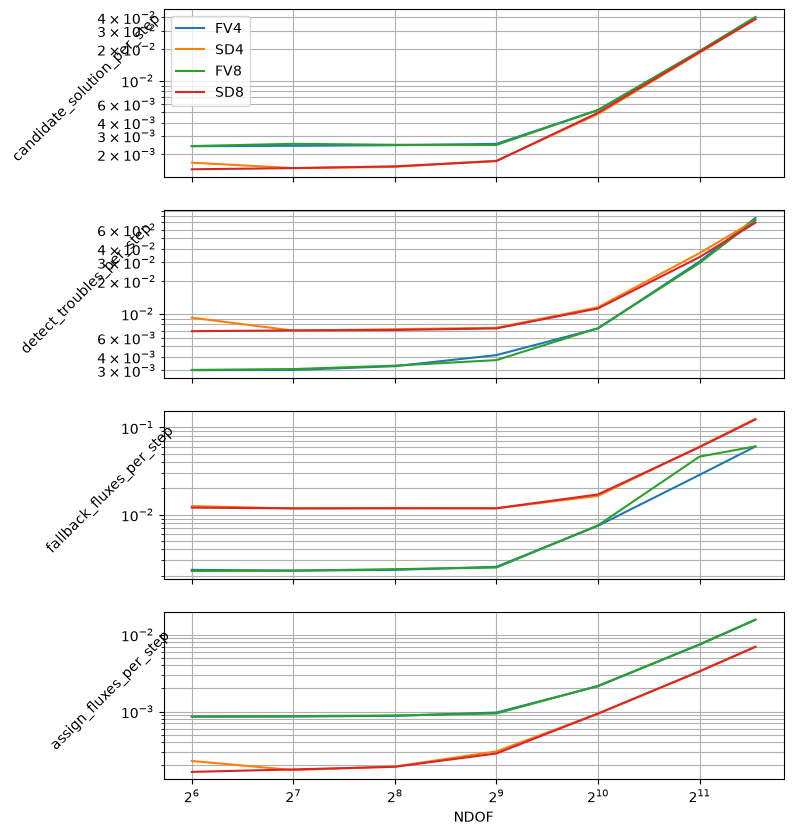

In [3]:
fig, axs = plt.subplots(len(MOOD_ROUTINES), 1, sharex=True, figsize=(8, 10))
axs[-1].set_xlabel("NDOF")
# axs[0].set_ylabel("DOF updates / s")
# axs[1].set_ylabel("RS time / step (s)")
# axs[2].set_ylabel("Limiter time / step (s)")
axs[0].set_xscale("log", base=2)
for ax in axs:
    ax.set_yscale("log")

for i, cat in enumerate(MOOD_ROUTINES):
    key = f"{cat}_per_step"
    axs[i].set_ylabel(key, rotation=45)
    plot(axs[i], df[(df.scheme == "FV") & (df.p == 3)], key, label="FV4")
    plot(axs[i], df[(df.scheme == "SD") & (df.p == 3)], key, label="SD4")
    plot(axs[i], df[(df.scheme == "FV") & (df.p == 7)], key, label="FV8")
    plot(axs[i], df[(df.scheme == "SD") & (df.p == 7)], key, label="SD8")

for ax in axs:
    ax.grid(which="both")
axs[0].legend()

fig.savefig("MOOD-breakdown.pdf", bbox_inches="tight")